### Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Step 2: Load Dataset

In [23]:
df = pd.read_csv("housing.csv")
df["price"].max()

15458287

### Step 3: EDA

In [4]:
df.head()
df.info() # It gives the infor about columns, rows, datatypes
# df.describe() # It gives statistical infor of the dataset
df.shape 
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       2000 non-null   int64
 1   bedrooms   2000 non-null   int64
 2   bathrooms  2000 non-null   int64
 3   stories    2000 non-null   int64
 4   parking    2000 non-null   int64
 5   price      2000 non-null   int64
dtypes: int64(6)
memory usage: 93.9 KB


Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price'], dtype='object')

### We use histogram to check the distribution of a single variable and below we are checking how the price variable is distributed in the data, detect outliers(these are the data points that are different or very far from rest of the data points but in our case price do not have outliers), and check whether data is balanced before modeling

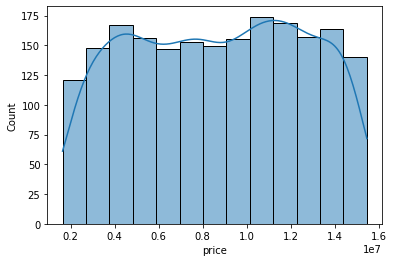

In [5]:
sns.histplot(df['price'], kde = True)
plt.show()

#### Now we want to know the relationship between price and area so we cannot use histogram in case we will use "Scatter plot" it handles two variable

### 🧑‍🏫 SCATTER PLOT (DEEP UNDERSTANDING)

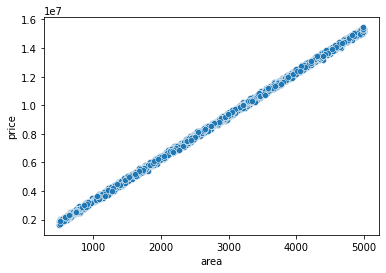

In [52]:
sns.scatterplot(x = 'area', y = 'price', data = df)
plt.show()

### 🔥 Step 2: Feature Relationships (VERY IMPORTANT) -> now we will check the relationship betweek each features so we will use corr(), it gives us the table in which it shows the realtionship between the features and how each features are affecting price

### 📝 Correlation

Correlation tells how strongly two variables are related

Value range:

+1 → strong positive relation

0 → no relation

-1 → strong negative relation

In [10]:
corr = df.corr()
corr

,area,bedrooms,bathrooms,stories,parking,price
area,1.000000,0.047523,0.021881,0.017749,-0.004031,0.999670
bedrooms,0.047523,1.000000,-0.011990,0.010435,0.006542,0.065752
bathrooms,0.021881,-0.011990,1.000000,0.029089,0.014528,0.030626
stories,0.017749,0.010435,0.029089,1.000000,-0.024558,0.026400
parking,-0.004031,0.006542,0.014528,-0.024558,1.000000,-0.000090
price,0.999670,0.065752,0.030626,0.026400,-0.000090,1.000000


### 🧑‍🏫 HEATMAP (VERY IMPORTANT)
1. 🔹 sns.heatmap() 👉 Draw heatmap graph
2. 🔹 corr 👉 Data (correlation table)
3. 🔹 annot=True 👉 Show numbers inside boxes
4.  🔹 cmap='coolwarm' 👉 Colors: Red → strong positive, Blue negative, Light → weak

### 🧠 FINAL MEANING OF THIS CODE

👉 “Show me all relationships between features using colors and numbers”

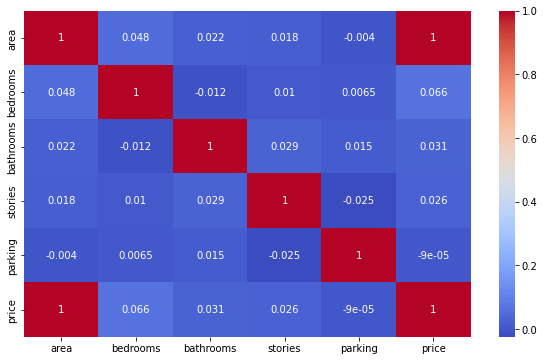

In [18]:
plt.figure(figsize = (10,6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.show()

## 🧑‍🏫 FIRST REGRESSION MODEL

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Now since we checked that the area is having strong positive relationship with price so we will test the model on area only for now

### 🎯 Step 1: Define Features & Target

In [5]:
x = df[['area']]
y = df['price']
print(y)

0        4631601
1       13384659
2       11059623
3        3269570
4       15104253
          ...   
1995    15458287
1996     9557403
1997     3628255
1998    12432040
1999     9360099
Name: price, Length: 2000, dtype: int64


### 🎯 Step 2: Train-Test Split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

### 🎯 Step 3: Train Model

In [7]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

### 🎯 Step 4: Predict

In [8]:
y_pred = model.predict(x_test)
print(y_pred[0])

2222070.3937378814


### 🧑‍🏫 EVALUATION METRICS -> Now we will do the evaluation of the model

### Calculate MAE

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mae

86317.98570973487

### Calculate MSE

In [10]:
mse = mean_squared_error(y_test, y_pred)
mse

10689002733.122726

### Calculate RMSE

In [12]:
import numpy as np

In [20]:
rmse = np.sqrt(mse)
print(rmse)

103387.63336648502


In [21]:
print(y_test[:5])
print(y_pred[:5])
print(df['price'].head())

1860     2195050
353     11689392
1333     5196977
905      5485692
1289     8176547
Name: price, dtype: int64
[ 2222070.39373788 11897619.32560125  5119031.21261723  5440248.62984013
  8018994.06343325]
0     4631601
1    13384659
2    11059623
3     3269570
4    15104253
Name: price, dtype: int64
